<a href="https://colab.research.google.com/github/SalomeAc/Redes-Entrega1/blob/main/Otra_copia_de_FirstDeliveryProyect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("indk214/brain-tumor-dataset-segmentation-and-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-dataset-segmentation-and-classification' dataset.
Path to dataset files: /kaggle/input/brain-tumor-dataset-segmentation-and-classification


In [3]:
plt.style.use('ggplot')
sns.set_palette("husl")

## Load Data

In [4]:
# data_path = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification/Training"

data_path = os.path.join(path, 'DATASET/classification/Training')

images = []
labels = []
img_sizes = []
img_modes = []

for subfolder in os.listdir(data_path):
    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)

        with Image.open(image_path) as img:
            img_sizes.append(img.size)
            img_modes.append(img.mode)

        images.append(image_path)
        labels.append(subfolder)

data = pd.DataFrame({'image_path': images, 'label': labels, 'image_size': img_sizes, 'image_mode': img_modes})

In [5]:
def display_sample_images(data):
    sampled_data = data.groupby('label').apply(lambda x: x.sample(1)).reset_index(drop=True)

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle('Sample Brain MRI Images (1 per class)', fontsize=16, fontweight='bold')

    for idx, (_, row) in enumerate(sampled_data.iterrows()):
        ax = axes[idx // 2, idx % 2]
        img = Image.open(row['image_path'])
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Class: {row['label']}\nSize: {img.size}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Data set overview

In [6]:
print("Dataset Overview:")
print(f"Total images: {len(data)}")
print(f"Classes: {data['label'].unique()}")
print(f"Class distribution:\n{data['label'].value_counts()}")
print(f"Image modes: {data['image_mode'].value_counts()}")
print(f"Unique image sizes: {data['image_size'].value_counts().head(5)}")


Dataset Overview:
Total images: 5712
Classes: ['pituitary' 'notumor' 'meningioma' 'glioma']
Class distribution:
label
notumor       1595
pituitary     1457
meningioma    1339
glioma        1321
Name: count, dtype: int64
Image modes: image_mode
L    5712
Name: count, dtype: int64
Unique image sizes: image_size
(512, 512)    3955
(225, 225)     268
(630, 630)      77
(236, 236)      53
(201, 251)      43
Name: count, dtype: int64


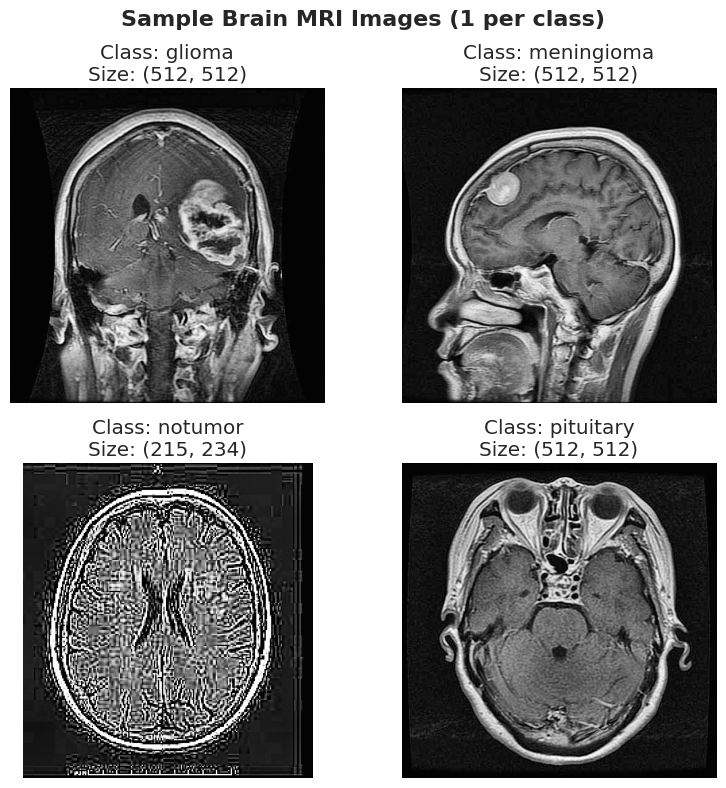

In [7]:
display_sample_images(data)

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, cohen_kappa_score, matthews_corrcoef,
                             log_loss, balanced_accuracy_score, jaccard_score,
                             hamming_loss, zero_one_loss)
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                    Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical

In [9]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# data_path = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification/Training"

data_path = os.path.join(path, 'DATASET/classification/Training')

images = []
labels = []
img_arrays = []

for subfolder in os.listdir(data_path):
    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)

        img = Image.open(image_path).convert('L')
        img = img.resize((128, 128))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=-1)

        images.append(image_path)
        labels.append(subfolder)
        img_arrays.append(img_array)

In [ ]:
data = pd.DataFrame({'image_path': images, 'label': labels})
X = np.array(img_arrays)
y = np.array(labels)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2,
                                                    stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                                  stratify=y_train, random_state=42)

y_train_cat = to_categorical(y_train, num_classes=len(le.classes_))
y_val_cat = to_categorical(y_val, num_classes=len(le.classes_))
y_test_cat = to_categorical(y_test, num_classes=len(le.classes_))

print(f"Training set: {X_train.shape}, {y_train_cat.shape}")
print(f"Validation set: {X_val.shape}, {y_val_cat.shape}")
print(f"Test set: {X_test.shape}, {y_test_cat.shape}")
print(f"Classes: {le.classes_}")

# Data augmentation and class weights balance

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# Model CNN Architecture

In [ ]:
model = Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(128, 128, 1)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
Dropout(0.2)

model.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
Dropout(0.5)


model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dropout(0.3))

model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))
model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))


model.add(Dense(4, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))



model.summary()

In [ ]:
# compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# callbacks

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

In [ ]:
history_cnn = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=30,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights,
    verbose=2
)

In [ ]:
model.load_weights('best_model.h5')

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

y_test_true = y_test

In [ ]:
metrics = {}

metrics['Accuracy'] = accuracy_score(y_test_true, y_pred)
metrics['Precision (Macro)'] = precision_score(y_test_true, y_pred, average='macro')
metrics['Recall (Macro)'] = recall_score(y_test_true, y_pred, average='macro')
metrics['F1-Score (Macro)'] = f1_score(y_test_true, y_pred, average='macro')
metrics['Precision (Micro)'] = precision_score(y_test_true, y_pred, average='micro')
metrics['Recall (Micro)'] = recall_score(y_test_true, y_pred, average='micro')
metrics['F1-Score (Micro)'] = f1_score(y_test_true, y_pred, average='micro')
metrics['Precision (Weighted)'] = precision_score(y_test_true, y_pred, average='weighted')
metrics['Recall (Weighted)'] = recall_score(y_test_true, y_pred, average='weighted')
metrics['F1-Score (Weighted)'] = f1_score(y_test_true, y_pred, average='weighted')

metrics['Cohen Kappa Score'] = cohen_kappa_score(y_test_true, y_pred)
metrics['Matthews Correlation Coefficient'] = matthews_corrcoef(y_test_true, y_pred)
metrics['Balanced Accuracy'] = balanced_accuracy_score(y_test_true, y_pred)
metrics['Jaccard Score (Macro)'] = jaccard_score(y_test_true, y_pred, average='macro')
metrics['Hamming Loss'] = hamming_loss(y_test_true, y_pred)
metrics['Zero-One Loss'] = zero_one_loss(y_test_true, y_pred)

In [ ]:
num_classes=4

y_test_bin = to_categorical(y_test_true, num_classes=num_classes)

roc_auc_scores = []
pr_auc_scores = []


for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_scores.append(auc(fpr, tpr))

    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc_scores.append(average_precision_score(y_test_bin[:, i], y_pred_proba[:, i]))

metrics['ROC AUC (Macro)'] = np.mean(roc_auc_scores)
metrics['PR AUC (Macro)'] = np.mean(pr_auc_scores)

metrics['Log Loss'] = log_loss(y_test_bin, y_pred_proba)

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print("\nEvaluation Metrics:")
print(metrics_df.round(4))

In [ ]:
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test_true, y_pred, target_names=le.classes_))

# Model MLP Architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# We assume your MRI images have been resized to 128x128 pixels and are grayscale (1 channel).
# Change this if your images are RGB (128, 128, 3) or a different size.
INPUT_SHAPE = (128, 128, 1)

# Building the MLP Classification Model directly using Sequential
model = Sequential([
    # 1. Input layer: Flatten the 2D image array into a 1D vector
    Flatten(input_shape=INPUT_SHAPE),

    # 2. First Hidden Block
    # Using L2 regularization to keep the neural weights from growing too large
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5), # Dropping 50% of connections to prevent memorization

    # 3. Second Hidden Block
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    # 4. Third Hidden Block
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    # 5. Output Layer: Exactly 4 neurons for your 4 brain tumor classes
    # Softmax ensures the outputs are probabilities that sum to 1
    Dense(4, activation='softmax')
])

# View the architecture and the parameter count
model.summary()

# Compiling the model for multi-class classification
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Slightly lower learning rate for MLPs
    loss='categorical_crossentropy', # Use 'sparse_categorical_crossentropy' if your labels are integers (0,1,2,3)
    metrics=['accuracy']
)

In [ ]:
history_mlp = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=30,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights,
    verbose=2
)

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

y_test_true = y_test

In [ ]:
metrics = {}

metrics['Accuracy'] = accuracy_score(y_test_true, y_pred)
metrics['Precision (Macro)'] = precision_score(y_test_true, y_pred, average='macro')
metrics['Recall (Macro)'] = recall_score(y_test_true, y_pred, average='macro')
metrics['F1-Score (Macro)'] = f1_score(y_test_true, y_pred, average='macro')
metrics['Precision (Micro)'] = precision_score(y_test_true, y_pred, average='micro')
metrics['Recall (Micro)'] = recall_score(y_test_true, y_pred, average='micro')
metrics['F1-Score (Micro)'] = f1_score(y_test_true, y_pred, average='micro')
metrics['Precision (Weighted)'] = precision_score(y_test_true, y_pred, average='weighted')
metrics['Recall (Weighted)'] = recall_score(y_test_true, y_pred, average='weighted')
metrics['F1-Score (Weighted)'] = f1_score(y_test_true, y_pred, average='weighted')

metrics['Cohen Kappa Score'] = cohen_kappa_score(y_test_true, y_pred)
metrics['Matthews Correlation Coefficient'] = matthews_corrcoef(y_test_true, y_pred)
metrics['Balanced Accuracy'] = balanced_accuracy_score(y_test_true, y_pred)
metrics['Jaccard Score (Macro)'] = jaccard_score(y_test_true, y_pred, average='macro')
metrics['Hamming Loss'] = hamming_loss(y_test_true, y_pred)
metrics['Zero-One Loss'] = zero_one_loss(y_test_true, y_pred)

In [ ]:
num_classes=4

y_test_bin = to_categorical(y_test_true, num_classes=num_classes)

roc_auc_scores = []
pr_auc_scores = []


for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_scores.append(auc(fpr, tpr))

    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc_scores.append(average_precision_score(y_test_bin[:, i], y_pred_proba[:, i]))

metrics['ROC AUC (Macro)'] = np.mean(roc_auc_scores)
metrics['PR AUC (Macro)'] = np.mean(pr_auc_scores)

metrics['Log Loss'] = log_loss(y_test_bin, y_pred_proba)

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print("\nEvaluation Metrics:")
print(metrics_df.round(4))

In [ ]:
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Learning curves
## CNN

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN - Accuracy vs Epochs')

plt.show()

# Loss
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN - Loss vs Epochs')

plt.show()

## MLP

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP - Accuracy vs Epochs')

plt.show()

# Loss
plt.plot(history_mlp.history['loss'], label='Train Loss')
plt.plot(history_mlp.history['val_loss'], label='Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP - Loss vs Epochs')

plt.show()

## CNN vs MLP

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')

plt.title('Comparación CNN vs MLP')
plt.legend()

plt.show()

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'CNN': cnn_metrics,
    'MLP': mlp_metrics
})

print(comparison_df)

In [ ]:
comparison_df.plot(kind='bar', figsize=(10,6))

plt.title('Comparación de métricas: CNN vs MLP')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=45)

plt.show()